# Question 8: Is there a difference in the number of double faults based on gender?

Using `statistics`, `home_team`, `away_team`

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [8]:
MINI_PROJECT_ROOT = Path.cwd().parents[2]

DATA_ROOT = (
    MINI_PROJECT_ROOT
    / "Tennis Schema"
    / "tennis_data"
)

PROCESSED_ROOT = DATA_ROOT / "processed"
TEAM_DATA_ROOT = PROCESSED_ROOT.parent / "Data"

In [9]:
statistics = pd.read_parquet(PROCESSED_ROOT / "statistics_clean.parquet")
home_team = pd.read_parquet(TEAM_DATA_ROOT / "home_team.parquet")
away_team = pd.read_parquet(TEAM_DATA_ROOT / "away_team.parquet")

statistics.loc[statistics["statistic_name"].str.contains("double", case=False, na=False), "statistic_name"].value_counts()

statistic_name
double_faults    76257
Name: count, dtype: int64

In [10]:
double_faults = statistics[statistics["statistic_name"] == "double_faults"]

double_faults.head()

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total,snapshot_date,invalid_team_stat
1,11998445,ALL,service,double_faults,2,7,2,negative,event,2.0,7.0,NaN,NaN,2024-02-01,False
21,11998445,1ST,service,double_faults,1,2,2,negative,event,1.0,2.0,NaN,NaN,2024-02-01,False
38,11998445,2ND,service,double_faults,1,2,2,negative,event,1.0,2.0,NaN,NaN,2024-02-01,False
55,11998445,3RD,service,double_faults,0,3,2,negative,event,0.0,3.0,NaN,NaN,2024-02-01,False
72,11998446,ALL,service,double_faults,2,1,1,negative,event,2.0,1.0,NaN,NaN,2024-02-01,False


In [18]:
# Check Matches Without an ALL Double-Fault Record
all_match_ids = set(double_faults["match_id"])

matches_with_all = set(double_faults.loc[double_faults["period"] == "ALL", "match_id"])

matches_without_all = all_match_ids - matches_with_all

len(matches_without_all)

0

In [11]:
# Keep Match-Level Double Fault Totals

double_faults_all = double_faults[double_faults["period"] == "ALL"]

double_faults_all[["match_id", "home_value", "away_value"]].head()

,match_id,home_value,away_value
1,11998445,2.0,7.0
72,11998446,2.0,1.0
126,11998447,0.0,5.0
179,11998448,2.0,2.0
233,11998449,2.0,3.0


In [12]:
# Keep the Latest Double Fault Snapshot per Match

double_faults_latest = (double_faults_all.sort_values("snapshot_date").drop_duplicates("match_id", keep="last"))

double_faults_latest[["match_id", "home_value", "away_value"]].head()

,match_id,home_value,away_value
10334,12021562,1.0,0.0
10388,12021566,6.0,2.0
10459,12021581,1.0,6.0
10530,12021589,7.0,2.0
10584,12021590,1.0,1.0


In [13]:
# Get Gender for Home and Away Players
home_gender = (home_team.sort_values("snapshot_date").drop_duplicates("match_id", keep="last")[["match_id", "gender"]].rename(columns={"gender": "home_gender"}))

away_gender = (away_team.sort_values("snapshot_date").drop_duplicates("match_id", keep="last") [["match_id", "gender"]].rename(columns={"gender": "away_gender"}))

home_gender.head()

,match_id,home_gender
564,12021318,F
563,12021309,M
562,12021294,M
561,12020718,F
560,12020624,F


In [14]:
double_faults_gender = (double_faults_latest.merge(home_gender, on="match_id", how="left").merge(away_gender, on="match_id", how="left"))

double_faults_gender[["match_id", "home_value", "away_value", "home_gender", "away_gender"]].head()

,match_id,home_value,away_value,home_gender,away_gender
0,12021562,1.0,0.0,F,F
1,12021566,6.0,2.0,F,F
2,12021581,1.0,6.0,M,M
3,12021589,7.0,2.0,F,F
4,12021590,1.0,1.0,M,M


In [15]:
double_faults_by_player = pd.concat([
    double_faults_gender[["home_gender", "home_value"]]
        .rename(columns={"home_gender": "gender", "home_value": "double_faults"}),

    double_faults_gender[["away_gender", "away_value"]]
        .rename(columns={"away_gender": "gender", "away_value": "double_faults"})
], ignore_index=True)

double_faults_by_player.head()

,gender,double_faults
0,F,1.0
1,F,6.0
2,M,1.0
3,F,7.0
4,M,1.0


In [16]:
gender_double_faults = (double_faults_by_player.groupby("gender")["double_faults"].mean().round(2))

gender_double_faults

gender
F    3.48
M    2.67
Name: double_faults, dtype: float64

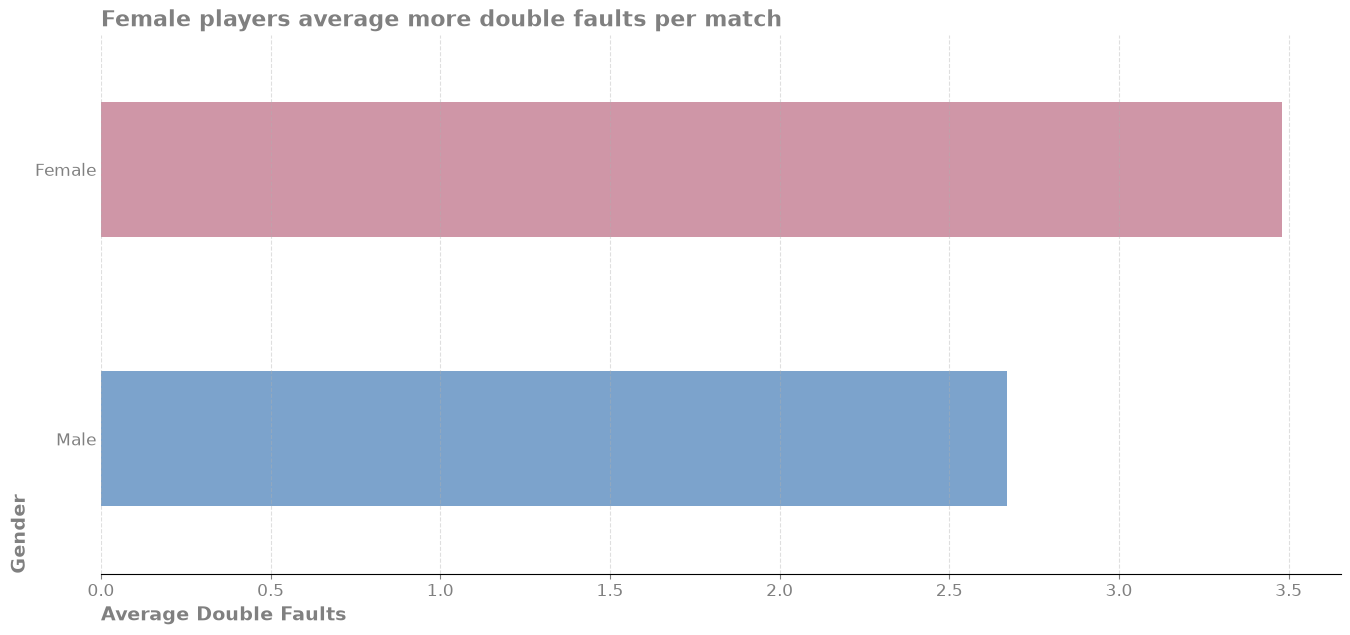

In [23]:
gender_plot = (gender_double_faults.rename({"F": "Female", "M": "Male"}).reset_index())

gender_plot.columns = ["gender", "avg_double_faults"]

fig, ax = plt.subplots(figsize=(16, 7))

sns.barplot(
    data=gender_plot,
    y="gender",
    x="avg_double_faults",
    hue="gender",
    palette={"Female": "#D98CA3", "Male": "#6FA3D9"},
    legend=False,
    orient="h",
    width=0.5,
    ax=ax)

ax.spines[["right", "left", "top"]].set_visible(False)

ax.set_title(
    "Female players average more double faults per match",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=16)

ax.set_xlabel(
    "Average Double Faults",
    weight="bold",
    color="gray",
    loc="left",
    fontsize=14)

ax.set_ylabel(
    "Gender",
    weight="bold",
    color="gray",
    loc="bottom",
    fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")
ax.tick_params(axis="y", which="major", length=0)

ax.grid(axis="x", linestyle="dashed", alpha=0.4)

plt.show()